**Import Libraries**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from collections import Counter
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, recall_score, precision_recall_curve, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

**Import data from CSV**

In [3]:
raw_df = pd.read_csv('/content/sample_data/fraudTest.csv')

In [5]:
raw_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [6]:
labels=["Genuine","Fraud"]

fraud_or_not = raw_df["is_fraud"].value_counts().tolist()
values = [fraud_or_not[0], fraud_or_not[1]]

fig = px.pie(values=raw_df['is_fraud'].value_counts(), names=labels , width=700, height=400, color_discrete_sequence=["skyblue","black"]
             ,title="Fraud vs Genuine transactions")
fig.show()

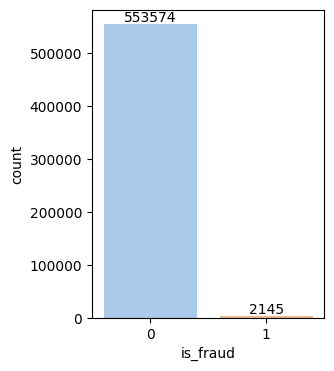

In [7]:
plt.figure(figsize=(3,4))
ax = sns.countplot(x='is_fraud', data=raw_df, palette="pastel", hue='is_fraud', legend=False)
for i in ax.containers:
    ax.bar_label(i,)
plt.show()

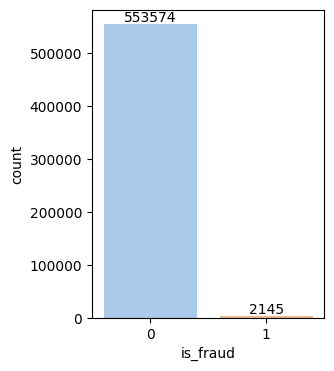

In [8]:
plt.figure(figsize=(3,4))
ax = sns.countplot(x='is_fraud', data=raw_df, palette="pastel", hue='is_fraud', legend=False)
for i in ax.containers:
    ax.bar_label(i,)
plt.show()

In [9]:
print('Genuine:', round(raw_df['is_fraud'].value_counts()[0]/len(raw_df) * 100,2), '% of the dataset')
print('Frauds:', round(raw_df['is_fraud'].value_counts()[1]/len(raw_df) * 100,2), '% of the dataset')

Genuine: 99.61 % of the dataset
Frauds: 0.39 % of the dataset


**Dropping Duplicated Values**

In [8]:
df = raw_df.copy()

df.drop_duplicates(inplace=True)
print("Duplicated values dropped succesfully")
print("*" * 100)

Duplicated values dropped succesfully
****************************************************************************************************


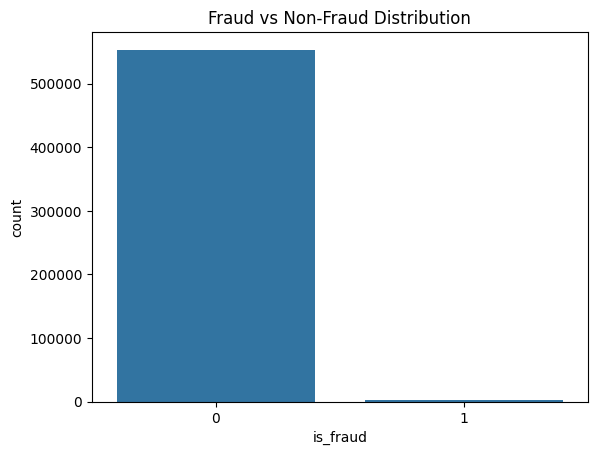

In [9]:
sns.countplot(x='is_fraud', data=df)
plt.title('Fraud vs Non-Fraud Distribution')
plt.show()

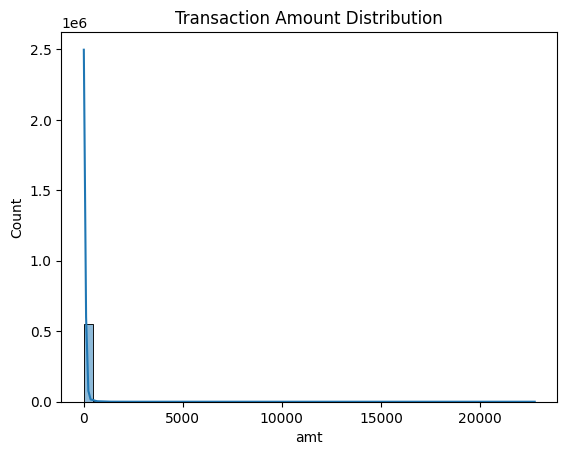

In [10]:
sns.histplot(df['amt'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

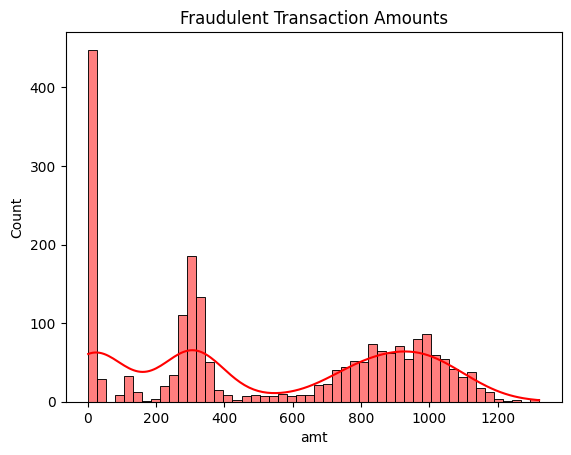

In [11]:
sns.histplot(df.loc[df['is_fraud']==1, 'amt'], bins=50, kde=True, color='red')
plt.title('Fraudulent Transaction Amounts')
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Separate high vs low cardinality
high_cardinality = [col for col in categorical_cols if df[col].nunique() > 50]
low_cardinality = [col for col in categorical_cols if df[col].nunique() <= 50]

# Label encode high-cardinality features
for col in high_cardinality:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# One-hot encode low-cardinality features
df = pd.get_dummies(df, columns=low_cardinality, drop_first=True)

# Define features and target
X = df.drop(columns=['is_fraud','trans_date_trans_time'])
y = df['is_fraud']


In [16]:
# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [17]:

# Handle imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [18]:
# --- Models ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_res, y_train_res)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [20]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[10:09:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='recall')

In [21]:
best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

print("Best XGBoost Parameters:", grid_search.best_params_)

Best XGBoost Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [22]:
# --- Evaluation ---
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

print("ROC-AUC Logistic Regression:", roc_auc_score(y_test, y_prob_lr))
print("ROC-AUC Random Forest:", roc_auc_score(y_test, y_prob_rf))
print("ROC-AUC XGBoost:", roc_auc_score(y_test, y_prob_xgb))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.00      0.00      0.00       429

    accuracy                           1.00    111144
   macro avg       0.50      0.50      0.50    111144
weighted avg       0.99      1.00      0.99    111144

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.82      0.62      0.71       429

    accuracy                           1.00    111144
   macro avg       0.91      0.81      0.85    111144
weighted avg       1.00      1.00      1.00    111144

XGBoost Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.71      0.85      0.78       429

    accuracy                           1.00    111144
   macro avg       0.86      0.93      0.89    111144
weigh

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



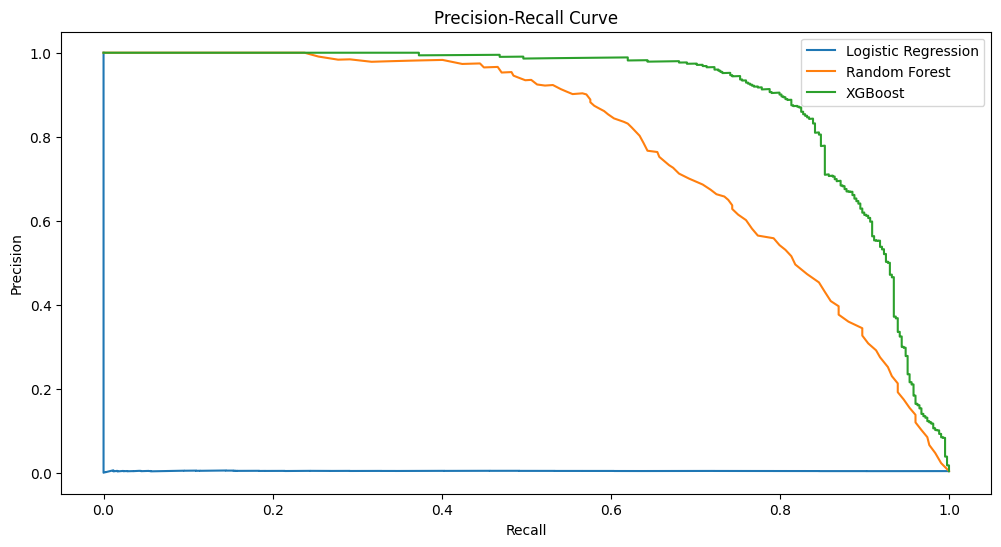

In [23]:
# Precision-Recall Curve
plt.figure(figsize=(12,6))
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(rec_lr, prec_lr, label='Logistic Regression')
plt.plot(rec_rf, prec_rf, label='Random Forest')
plt.plot(rec_xgb, prec_xgb, label='XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

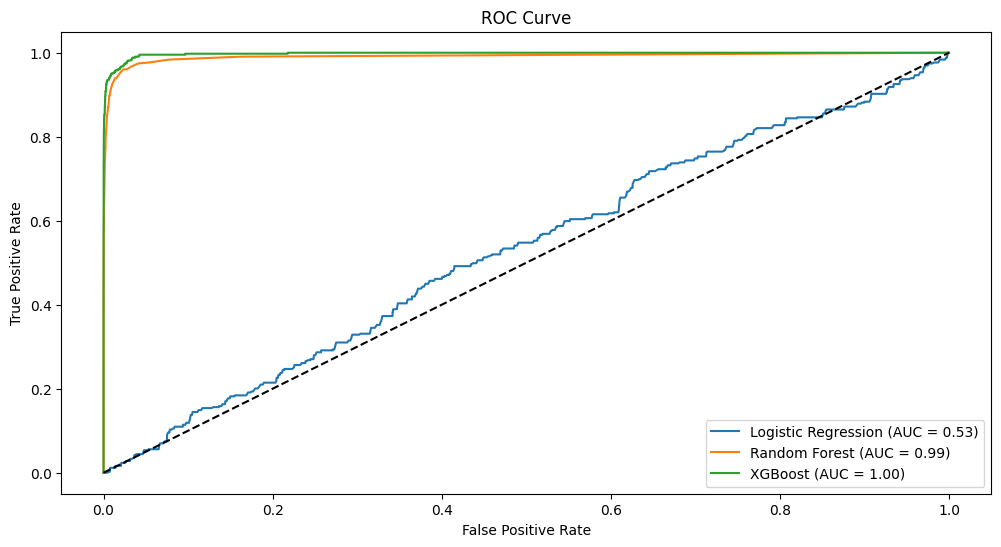

In [24]:
# ROC Curve
plt.figure(figsize=(12,6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = %0.2f)' % auc(fpr_lr, tpr_lr))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % auc(fpr_rf, tpr_rf))
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = %0.2f)' % auc(fpr_xgb, tpr_xgb))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [26]:
# --- Cost-Benefit Analysis ---
months = df['trans_date_trans_time'].apply(pd.to_datetime).dt.to_period('M').nunique()
avg_txn_per_month = len(df) / months
avg_fraud_txn_per_month = df['is_fraud'].sum() / months
avg_amt_fraud_txn = df.loc[df['is_fraud'] == 1, 'amt'].mean()

cost_before = avg_amt_fraud_txn * avg_fraud_txn_per_month
recall_xgb = recall_score(y_test, y_pred_xgb)
TF = avg_fraud_txn_per_month * recall_xgb
FN = avg_fraud_txn_per_month * (1 - recall_xgb)

cost_after = (1.5 * TF) + (avg_amt_fraud_txn * FN)
savings = cost_before - cost_after

print("Cost per month before deployment:", cost_before)
print("Cost per month after deployment:", cost_after)
print("Final monthly savings:", savings)

# Best model selection
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
best_model = max([(auc_lr, 'Logistic Regression'), (auc_rf, 'Random Forest'), (auc_xgb, 'XGBoost')], key=lambda x: x[0])
print("Best model based on ROC-AUC:", best_model[1])

Cost per month before deployment: 1133324.68
Cost per month after deployment: 169177.2956643357
Final monthly savings: 964147.3843356642
Best model based on ROC-AUC: XGBoost
